# Steps that end on a real simulated hit (Block C, C5)

This notebook **computes nothing**. It loads what `build_hit_set.py`,
`score_hits.py` and `plot.py` wrote and displays it. Every number below is read
from `results/`; the argument that goes with them is in [README.md](README.md).

The subject: take a step whose start and end states are both **measured
crossings of a sensor plane by the same simulated particle**, and ask three
field-only extrapolators to predict the end state from the start state. None of
them can model multiple scattering or energy loss, so the fine reference's own
miss is the **material floor** and everything else is read against it.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 300)
RESULTS, FIGURES = "results", "figures"

setm = json.load(open(os.path.join(RESULTS, "hit_set_meta.json")))
scm = json.load(open(os.path.join(RESULTS, "hit_scoring_meta.json")))
T = pd.read_csv(os.path.join(RESULTS, "hit_table.csv"))
STRATA = [s["stratum"] for s in setm["per_stratum"]]
BANDS = [b["name"] for b in setm["p_bands"]]
T["stratum"] = pd.Categorical(T["stratum"], STRATA + ["all"], ordered=True)
print(setm["n_rows"], "rows from", setm["n_particles"], "particles")
print("field:", scm["field"]["which"], scm["field"]["md5"])
print("scheme converged fraction:", scm["scheme"]["converged_fraction"],
      " max residual:", scm["scheme"]["max_residual"])

13228 rows from 2268 particles
field: up 9e49ddc4313b589f273540e7e0bb513b
scheme converged fraction: 1.0  max residual: 4.451994328746878e-11


## C5.1 The set

The cut cascade, from `results/hit_set_meta.json`. The two split cuts are the
ones that matter: the particle must be in the **v2 test** split, and must not be
in the **magnet_tracks_v3 train or val** split, which is where the grid networks
were fitted.

In [2]:
display(pd.DataFrame(setm["cut_cascade"]))
display(pd.DataFrame(setm["per_stratum"]))
display(pd.DataFrame(setm["p_bands"]))
print("plane pairs:", setm["plane_pairs"])
print("directions:", setm["direction_counts"])
print()
print("LABEL CAVEAT:", setm["label_caveat"])

,cut,pairs_out,particles_out,note
0,consecutive plane crossings of one particle (f...,1080237,147609,sorted by z within the particle
1,|dz| >= 0.05 mm,1072707,146983,below this the two hits are the two faces of o...
2,both planes inside 2200 < z < 9500 mm,688406,105170,"the network's (z0, dz) normalisation is the ma..."
3,2 < eta < 5,510748,67477,
4,1 < p < 200 GeV,398317,38871,
5,non-electron,317315,29535,"an electron's residual is bremsstrahlung, a di..."
6,the particle is in the v2 TEST split,31640,2926,"80/10/10 by particle, seed 20260718"
7,the particle is NOT in the magnet_tracks_v3 tr...,24598,2436,7042 pairs removed: the v3 split is 60/20/20 o...
8,both directions,49196,2436,the reversed pair ends on the earlier hit's me...


,stratum,index,abs_dz_mm,available,cap,drawn
0,0.05-2 mm,0,"[0.05, 2.0]",436,4000,436
1,2-20 mm,1,"[2.0, 20.0]",382,4000,382
2,20-200 mm,2,"[20.0, 200.0]",36150,6000,6000
3,200-2000 mm,3,"[200.0, 2000.0]",9818,4000,4000
4,cross-magnet,4,"[2000.0, None]",2410,3000,2410


,name,lo,hi,n
0,1-5 GeV,1.0,5.0,6526
1,5-20 GeV,5.0,20.0,5212
2,20-200 GeV,20.0,200.0,1490


plane pairs: {'FT->FT': 8113, 'FT->UT': 1205, 'UT->FT': 1205, 'UT->UT': 2705}
directions: {'forward': 6669, 'backward': 6559}

LABEL CAVEAT: the v2 rows' Y column is field-only propagation on the MagDown map and is NOT used anywhere in this folder; the end state is the particle's own next hit


## C5.2 The table

`results/hit_table.csv`. `vs_hit` is the error against the particle's own next
hit; `vs_reference` is the error against the fine reference's answer from the
same start state, i.e. the field-only error.

In [3]:
def view(band="all", direction="all"):
    m = T[(T.p_band == band) & (T.direction == direction)
          & (T.predictor != "network (every seed)")]
    return (m.pivot_table(index=["predictor", "arch", "mode"],
                          columns="stratum", values="vs_hit_med_um",
                          observed=True)
            .style.format("{:.4g}"))

print("median error against the real next hit, um - all momenta")
display(view())

median error against the real next hit, um - all momenta


In [4]:
for b in BANDS:
    print("median error against the real next hit, um -", b)
    display(view(band=b))

median error against the real next hit, um - 1-5 GeV


median error against the real next hit, um - 5-20 GeV


median error against the real next hit, um - 20-200 GeV


The same predictors scored against the **fine reference** instead of the hit.
Where these numbers are below the floor of the panel above, the comparison
against hits cannot separate that predictor from the reference.

In [5]:
m = T[(T.p_band == "all") & (T.direction == "all")
      & (T.predictor != "network (every seed)")]
display(m.pivot_table(index=["predictor", "arch", "mode"], columns="stratum",
                      values="vs_reference_med_um", observed=True)
        .style.format("{:.4g}"))

The excess over the material floor, per momentum band: the network's median
divided by the fine reference's median on the same rows.

In [6]:
floor = (T[(T.predictor == "fine reference (material floor)")
           & (T.direction == "all")]
         .set_index(["stratum", "p_band"]).vs_hit_med_um)
net = T[(T.predictor == "network (best val seed)") & (T.direction == "all")].copy()
net["over_floor"] = net.apply(
    lambda r: r.vs_hit_med_um / floor.loc[(r.stratum, r.p_band)], axis=1)
for b in ["all"] + BANDS:
    print("network median / material floor -", b)
    display(net[net.p_band == b]
            .pivot_table(index=["arch", "mode"], columns="stratum",
                         values="over_floor", observed=True)
            .style.format("{:.3g}"))

network median / material floor - all


network median / material floor - 1-5 GeV


network median / material floor - 5-20 GeV


network median / material floor - 20-200 GeV


The tails, and the seed spread the "best val seed" choice was made inside.

In [7]:
display(T[(T.p_band == "all") & (T.direction == "all")
          & (T.predictor != "network (every seed)")]
        .pivot_table(index=["predictor", "arch", "mode"], columns="stratum",
                     values="vs_hit_p95_um", observed=True)
        .style.format("{:.4g}"))
print("the seed chosen per (architecture, arm, stratum):")
display(pd.Series(scm["seed_selection"]["chosen"]).to_frame("seed").T)
print("stratum match used for the choice:", scm["seed_selection"]["stratum_match"])

the seed chosen per (architecture, arm, stratum):


,2x256 data 0.05-2 mm,2x256 data 2-20 mm,2x256 data 20-200 mm,2x256 data 200-2000 mm,2x256 data cross-magnet,2x256 physics 0.05-2 mm,2x256 physics 2-20 mm,2x256 physics 20-200 mm,2x256 physics 200-2000 mm,2x256 physics cross-magnet,4x64 data 0.05-2 mm,4x64 data 2-20 mm,4x64 data 20-200 mm,4x64 data 200-2000 mm,4x64 data cross-magnet,4x64 physics 0.05-2 mm,4x64 physics 2-20 mm,4x64 physics 20-200 mm,4x64 physics 200-2000 mm,4x64 physics cross-magnet,8x128 data 0.05-2 mm,8x128 data 2-20 mm,8x128 data 20-200 mm,8x128 data 200-2000 mm,8x128 data cross-magnet,8x128 physics 0.05-2 mm,8x128 physics 2-20 mm,8x128 physics 20-200 mm,8x128 physics 200-2000 mm,8x128 physics cross-magnet,8x256 data 0.05-2 mm,8x256 data 2-20 mm,8x256 data 20-200 mm,8x256 data 200-2000 mm,8x256 data cross-magnet,8x256 physics 0.05-2 mm,8x256 physics 2-20 mm,8x256 physics 20-200 mm,8x256 physics 200-2000 mm,8x256 physics cross-magnet
seed,2,2,2,2,2,2,2,2,0,1,1,1,1,1,1,1,1,1,0,1,2,0,0,0,0,2,2,2,1,0,0,0,0,0,0,1,1,2,2,1


stratum match used for the choice: {'0.05-2 mm': '0.5-2 mm', '2-20 mm': '5-20 mm', '20-200 mm': '50-200 mm', '200-2000 mm': '500-2000 mm', 'cross-magnet': 'full crossing'}


## C5.3 The figure

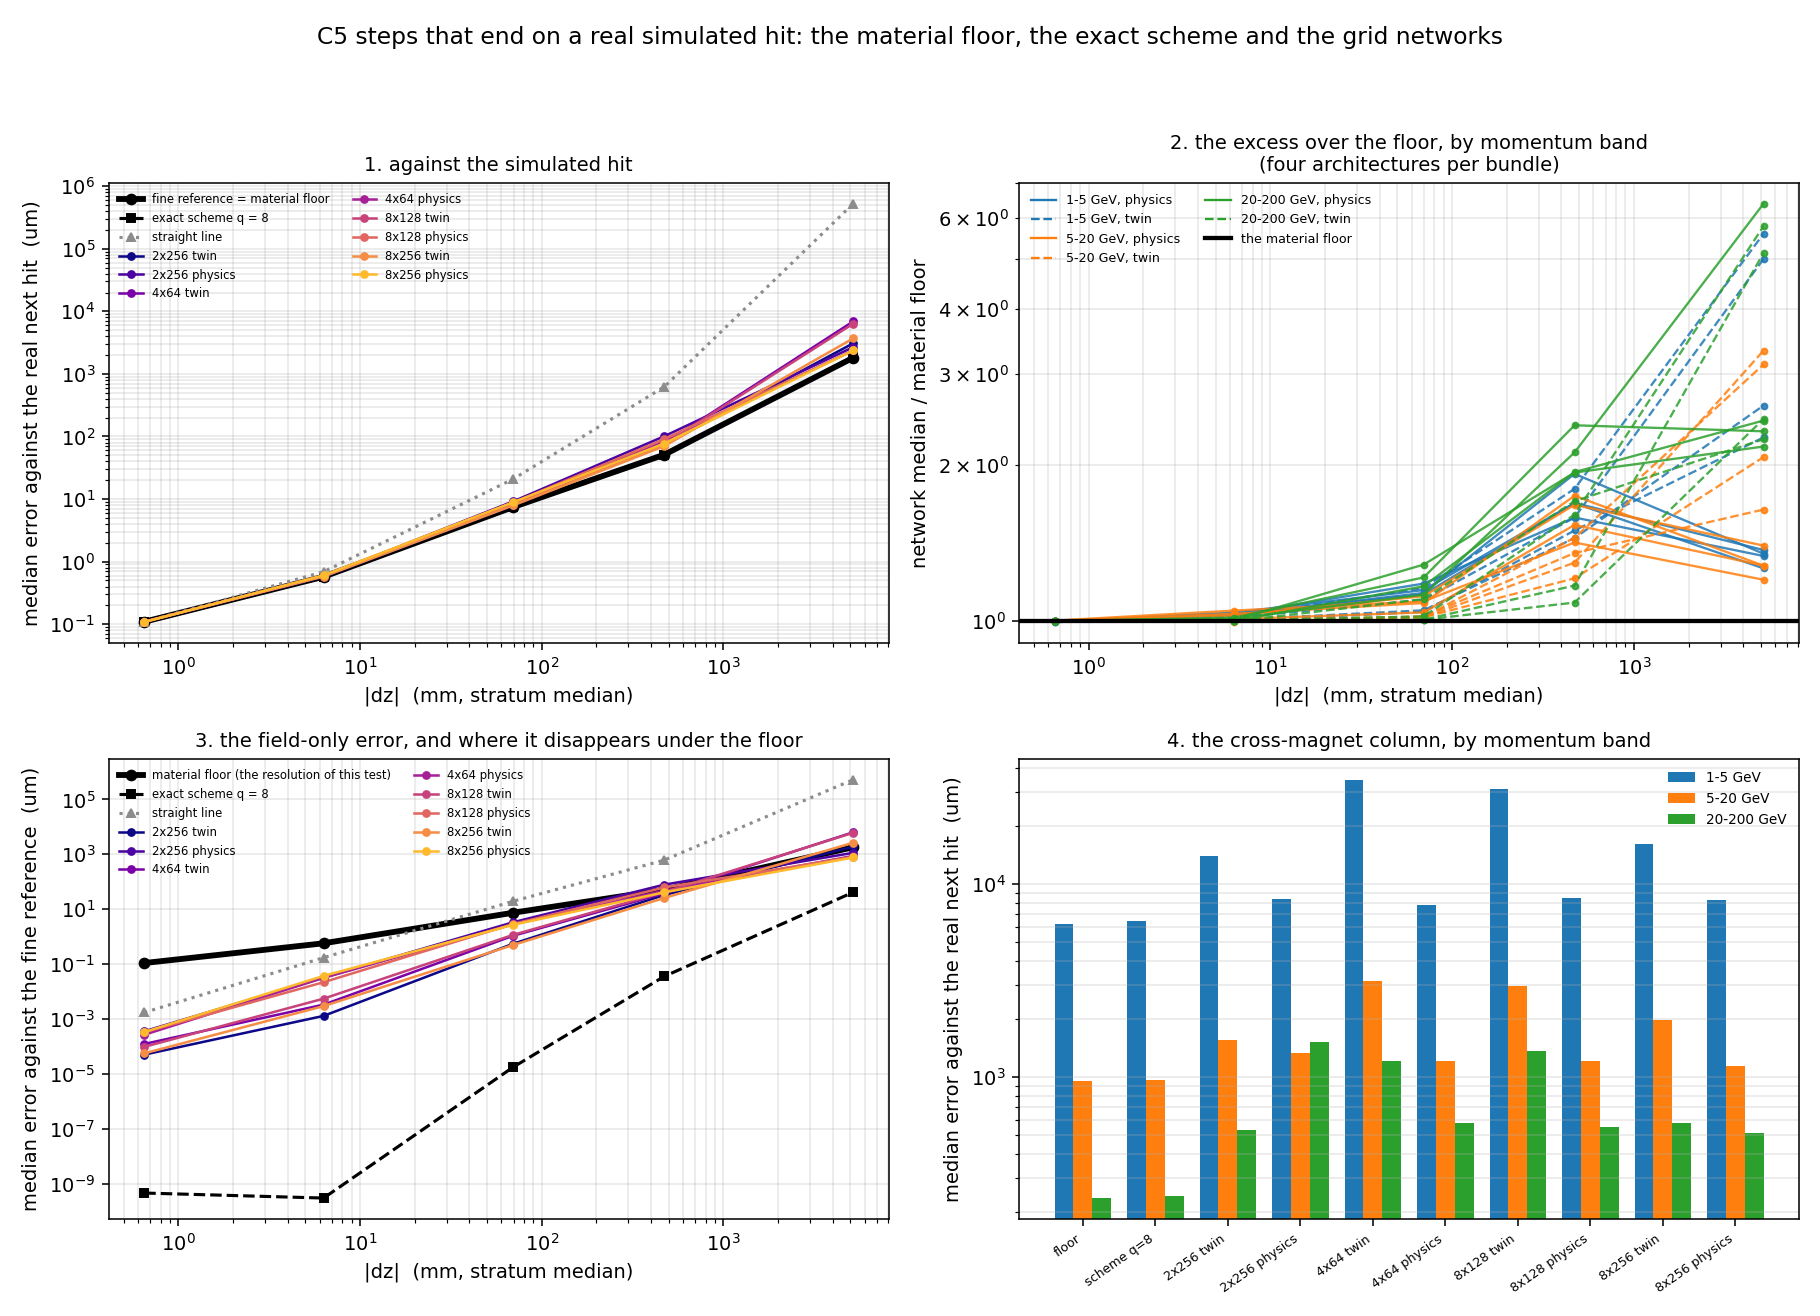

In [8]:
display(Image(filename=os.path.join(FIGURES, "hit_comparison.png")))